In [2]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
my_key = '722729cfa99e33f0f76a6c4385beb4a6394f1728'

## US Census: Finding variable code
When you're trying to web-scrape a Census variable, the safest way is to check the official variables.json metadata file (for example: https://api.census.gov/data/2024/acs/acs1/subject/variables.json) and search for keywords to find the exact variable code.

## Function to fetch multiple variables from United States Census Bureau

In [4]:
def fetch_msa_variable_acs1_recent_n_years(var_code: str, var_name: str, api_key: str, n_years: int, max_lookback: int = 10):
    """
    Fetch one ACS1 variable for all MSAs for the most recent n available years.
    """
    current_year = datetime.today().year
    dfs = []
    collected = 0

    for year in range(current_year, current_year - max_lookback, -1):
        if collected >= n_years:
            break

        if var_code.startswith("S"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/subject"
        elif var_code.startswith("B"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1"
        elif var_code.startswith("D"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/profile"
        else:
            raise ValueError("Unsupported variable code prefix")

        params = {
            "get": f"NAME,{var_code}",
            "for": "metropolitan statistical area/micropolitan statistical area:*",
            "key": api_key
        }

        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            continue

        data = response.json()
        if len(data) <= 1:
            continue

        df = pd.DataFrame(data[1:], columns=data[0])
        if var_code not in df.columns:
            continue

        df = df.rename(columns={
            var_code: var_name,
            "NAME": "msa_name",
            "metropolitan statistical area/micropolitan statistical area": "msa_code"
        })

        df[var_name] = pd.to_numeric(df[var_name], errors="coerce")
        df["year"] = year

        dfs.append(df[["msa_code", "msa_name", "year", var_name]])
        collected += 1

    if not dfs:
        raise RuntimeError("No available data found")

    return pd.concat(dfs, ignore_index=True)

In [5]:
# Collect useful variables and their Census API codes
variables_acs1 = {
    "Total_Population":       "B01003_001E",
    "Laborforce_Population":  "DP03_0002E",
    "Employed":               "DP03_0004E",
    "Median_Household_Income":"S1903_C03_001E",
    "Median_House_Value":     "B25077_001E",
    "Total_Housing_Units":    "B25002_001E",
    "House_Occupied":         "B25002_002E",
    "House_Vacant":           "B25002_003E",
    "Median_Gross_Rent":      "B25064_001E",
    "5_to_9_units":           "DP04_0011E",
    "10_to_19_units":         "DP04_0012E",
    "20_or_more_units":       "DP04_0013E"
}

In [6]:
# Fetch ACS1 variables for all MSAs for n+1 years
# n+1 years needed to compute growth factors (e.g. population growth)
dfs = []
for var_name, var_code in variables_acs1.items():
    df = fetch_msa_variable_acs1_recent_n_years(
        var_code=var_code, var_name=var_name, api_key=my_key, n_years=5+1
    )
    dfs.append(df)

In [7]:
# Merge all variables into a single master table
msa_features = reduce(
    lambda left, right: pd.merge(left, right, on=["msa_code", "msa_name", "year"], how="outer"),
    dfs
)
msa_features = msa_features.sort_values(by=['msa_code', 'year'])

# Construct total multifamily units
msa_features['Total_Multi_Units'] = (
    msa_features['5_to_9_units'] +
    msa_features['10_to_19_units'] +
    msa_features['20_or_more_units']
)

# Filter: Metro Areas with population >= 300,000
population_requirement = 300_000
most_recent_year = msa_features['year'].max()

eligible_msa = msa_features.loc[
    (msa_features['year'] == most_recent_year) &
    (msa_features['Total_Population'] >= population_requirement) &
    (msa_features['msa_name'].str.endswith('Metro Area')),
    'msa_code'
].unique()

msa_features = msa_features[msa_features['msa_code'].isin(eligible_msa)]

print(f"By year {most_recent_year}, {msa_features['msa_code'].nunique()} MSAs have population over {population_requirement:,}.")

By year 2024, 173 MSAs have population over 300,000.


## External Data: Cap Rate, Tax Rate & OER

Upload both Excel files when prompted:
- `State_Property_Tax.xlsx` — sheet `Tax new`: columns `State`, `MSA (Core County)`, `Hotel Effective Rate`, `Multifamily Effective Rate`
- `Cap_Rate_Gemini.xlsx` — sheet `cap rate`: columns `State Code`, `State`, `Hotel Cap`, `Multifamily Cap`, `Cap Spread`
- `Cap_Rate_Gemini.xlsx` — sheet `OER`: columns `msa_code`, `Operating Expense Ratio (OER)`

> Note: Tax table uses full State name; Cap Rate table has both `State Code` and `State`.
> The two are joined on `State` (full name), then merged into Census data via `State Code`.

In [10]:

# ── Tax Rate (State-level, keyed by State full name) ───────────────
df_tax = pd.read_excel('State Property Tax.xlsx', sheet_name='Tax new')
df_tax['Diff_Effective_Rate'] = (
    df_tax['Hotel Effective Rate'] - df_tax['Multifamily Effective Rate']
)

# ── Cap Rate (State-level, has State Code + State full name) ────────
df_cap = pd.read_excel('Cap_Rate_Gemini (1).xlsx', sheet_name='cap rate')
# Cap Spread already in file, but recompute to be safe
df_cap['Cap Spread'] = df_cap['Hotel Cap'] - df_cap['Multifamily Cap']

# ── Join Tax into Cap on State full name → gives us State Code ──────
df_cap_tax = pd.merge(
    df_cap[['State Code', 'State', 'Hotel Cap', 'Multifamily Cap', 'Cap Spread']],
    df_tax[['State', 'Hotel Effective Rate', 'Multifamily Effective Rate', 'Diff_Effective_Rate']],
    on='State', how='left'
)

print(f"Cap/Tax table: {len(df_cap_tax)} states")
df_cap_tax.head()

Cap/Tax table: 48 states


,State Code,State,Hotel Cap,Multifamily Cap,Cap Spread,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,AZ,Arizona,0.0825,0.055,0.0275,0.01445,0.00932,0.00513
1,AL,Alabama,0.0875,0.070,0.0175,0.01450,0.00725,0.00725
2,AR,Arkansas,0.0900,0.065,0.0250,0.01404,0.01404,0.00000
3,CA,California,0.0750,0.051,0.0240,0.01250,0.01250,0.00000
4,CO,Colorado,0.0800,0.053,0.0270,0.01990,0.00554,0.01436


In [11]:
# ── OER (MSA-level) from Excel ────────────────────────────────────
df_oer = pd.read_excel('Cap_Rate_Gemini (1).xlsx', sheet_name='OER')
df_oer = df_oer.rename(columns={'Operating Expense Ratio (OER)': 'OER'})
df_oer['msa_code'] = df_oer['msa_code'].astype(str)

print(f"OER data loaded: {len(df_oer)} MSAs")
df_oer.head()

OER data loaded: 169 MSAs


,msa_code,msa_name,City Used,OER
0,10420,"Akron, OH",Akron,0.431
1,10580,"Albany-Schenectady-Troy, NY",Albany,0.408
2,10740,"Albuquerque, NM",Albuquerque,0.446
3,10900,"Allentown-Bethlehem-Easton, PA-NJ",Allentown,0.392
4,11460,"Ann Arbor, MI",Ann Arbor,0.422


## Merging Census data with external data

- **Cap Rate & Tax Rate**: Merged on `State Code` (extracted from MSA name)
- **OER**: Merged on `msa_code`

Example:  
`'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Metro Area'` → State Code = `'PA'`

In [22]:
# Normalize column names in case previous merges created suffixes
if 'msa_name' not in msa_features.columns:
    if 'msa_name_x' in msa_features.columns:
        msa_features = msa_features.rename(columns={'msa_name_x': 'msa_name'})
    elif 'msa_name_y' in msa_features.columns:
        msa_features = msa_features.rename(columns={'msa_name_y': 'msa_name'})

# Remove old market metric columns so reruns do not create merge collisions
metric_cols = [
    'Hotel Cap', 'Multifamily Cap', 'Cap Spread',
    'Hotel Effective Rate', 'Multifamily Effective Rate', 'Diff_Effective_Rate', 'OER'
 ]
drop_metrics = []
for col in metric_cols:
    for c in [col, f'{col}_x', f'{col}_y']:
        if c in msa_features.columns:
            drop_metrics.append(c)
if drop_metrics:
    msa_features = msa_features.drop(columns=sorted(set(drop_metrics)))

# Extract State Code and Principal City from MSA name
def extract_principal_state(msa_name):
    return msa_name.split(', ')[1].split(' ')[0].split('-')[0]

def extract_principal_city(msa_name):
    return msa_name.split(',')[0].split('-')[0]

msa_features['State Code'] = msa_features['msa_name'].apply(extract_principal_state)
msa_features['Principal_City'] = msa_features['msa_name'].apply(extract_principal_city)

# Keep only columns needed for state-level metrics
cap_tax_cols = [
    'State Code', 'Hotel Cap', 'Multifamily Cap', 'Cap Spread',
    'Hotel Effective Rate', 'Multifamily Effective Rate', 'Diff_Effective_Rate'
]

# Build an msa_code-level lookup table, then merge by msa_code
df_cap_tax_by_msa = (
    msa_features[['msa_code', 'State Code']]
    .drop_duplicates()
    .merge(df_cap_tax[cap_tax_cols], on='State Code', how='left')
)

# Merge Cap Rate and Tax Rate (state-level data expanded to msa_code-level)
msa_features['msa_code'] = msa_features['msa_code'].astype(str)
msa_features = pd.merge(
    msa_features,
    df_cap_tax_by_msa.drop(columns=['State Code']),
    on='msa_code', how='left'
 )

# Merge OER (msa_code-level)
df_oer_merge = df_oer[['msa_code', 'OER']].copy()
df_oer_merge['msa_code'] = df_oer_merge['msa_code'].astype(str)
msa_features = pd.merge(msa_features, df_oer_merge, on='msa_code', how='left')

msa_features = msa_features.dropna()
print(f"Master table: {msa_features['msa_code'].nunique()} MSAs, {len(msa_features)} rows")
msa_features.head()

Master table: 164 MSAs, 984 rows


,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,State Code,Principal_City,City Used,Hotel Cap,Multifamily Cap,Cap Spread,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,OER
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,OH,Akron,Akron,0.0865,0.067,0.0195,0.0406,0.01406,0.02654,0.431
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,OH,Akron,Akron,0.0865,0.067,0.0195,0.0406,0.01406,0.02654,0.431
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,OH,Akron,Akron,0.0865,0.067,0.0195,0.0406,0.01406,0.02654,0.431
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,OH,Akron,Akron,0.0865,0.067,0.0195,0.0406,0.01406,0.02654,0.431
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,OH,Akron,Akron,0.0865,0.067,0.0195,0.0406,0.01406,0.02654,0.431


# Factor Creation

11 factors across 6 indices, following the defined methodology:

### Economic Index
$$Employment\ Rate = \frac{Employed}{Laborforce\ Population}$$
$$Employment\ Growth = \frac{Employed_t - Employed_{t-1}}{Employed_{t-1}}$$
$$Population\ Growth = \frac{Total\ Pop_t - Total\ Pop_{t-1}}{Total\ Pop_{t-1}}$$
$$Income\ Growth = \frac{Median\ Income_t - Median\ Income_{t-1}}{Median\ Income_{t-1}}$$

### Housing Stability Index
$$Rent\ to\ Income\ Ratio = \frac{Median\ Gross\ Rent}{Median\ Income}$$
$$Vacancy\ Rate = \frac{House\ Vacant}{Total\ Housing\ Units}$$

### Supply Pressure Index
$$New\ Multi\ Units = Total\ Multi\ Units_t - Total\ Multi\ Units_{t-1}$$

### Pricing Power Index
$$Rent\ Growth = \frac{Median\ Gross\ Rent_t - Median\ Gross\ Rent_{t-1}}{Median\ Gross\ Rent_{t-1}}$$

### Valuation Index
$$Implied\ Value = \frac{Annual\ Rent \times (1 - OER)}{Multifamily\ Cap\ Rate}$$

### Capital Market Index
$$Cap\ Spread = Cap\ Rate_{hotel} - Cap\ Rate_{multifamily}$$
$$Effective\ Tax\ Spread = Effective\ Tax\ Rate_{hotel} - Effective\ Tax\ Rate_{multifamily}$$

In [24]:
# Drop helper columns before factor computation
data = msa_features.drop(columns=['State Code', 'Principal_City'])
earliest_year = data['year'].min()

# ── Economic Index factors ─────────────────────────────────────────
data['Employment_Rate']   = data['Employed'] / data['Laborforce_Population']
data['Employment_Growth'] = data.groupby('msa_code')['Employed'].pct_change()
data['Pop_Growth']        = data.groupby('msa_code')['Total_Population'].pct_change()
data['Income_Growth']     = data.groupby('msa_code')['Median_Household_Income'].pct_change()

# ── Housing Stability Index factors ───────────────────────────────
# Vacancy Rate: House_Vacant / Total_Housing_Units (per methodology)
data['Vacancy_Rate']       = data['House_Vacant'] / data['Total_Housing_Units']
data['Rent_to_Income_Ratio'] = data['Median_Gross_Rent'] / data['Median_Household_Income']

# ── Supply Pressure Index factors ─────────────────────────────────
data['New_Multi_Units'] = data.groupby('msa_code')['Total_Multi_Units'].diff()
# Fix outliers: negative values (from MSA rezoning) set to 0
data['New_Multi_Units'] = data['New_Multi_Units'].clip(lower=0)

# ── Pricing Power Index factors ────────────────────────────────────
data['Rent_Growth'] = data.groupby('msa_code')['Median_Gross_Rent'].pct_change()

# ── Valuation Index factors ────────────────────────────────────────
# Annual Rent = Median_Gross_Rent * 12
data['Implied_Value'] = (
    data['Median_Gross_Rent'] * 12 * (1 - data['OER'])
) / data['Multifamily Cap']

# ── Capital Market Index factors ───────────────────────────────────
# Cap Spread and Diff_Effective_Rate already computed during merge

# ── Final factor list (11 factors, per methodology) ───────────────
factor_list = [
    # Economic Index
    'Employment_Rate', 'Employment_Growth', 'Pop_Growth', 'Income_Growth',
    # Housing Stability Index
    'Rent_to_Income_Ratio', 'Vacancy_Rate',
    # Supply Pressure Index
    'New_Multi_Units',
    # Pricing Power Index
    'Rent_Growth',
    # Valuation Index
    'Implied_Value',
    # Capital Market Index
    'Cap Spread', 'Diff_Effective_Rate'
]

factor_df = data[['msa_code', 'msa_name', 'year'] + factor_list].copy()
factor_df = factor_df[factor_df['year'] > earliest_year]  # drop base year (no growth data)
factor_df = factor_df.dropna()

print(f"Factor table: {factor_df['msa_code'].nunique()} MSAs, {len(factor_df)} rows")
factor_df.head()

Factor table: 164 MSAs, 820 rows


,msa_code,msa_name,year,Employment_Rate,Employment_Growth,Pop_Growth,Income_Growth,Rent_to_Income_Ratio,Vacancy_Rate,New_Multi_Units,Rent_Growth,Implied_Value,Cap Spread,Diff_Effective_Rate
1,10420,"Akron, OH Metro Area",2019,0.945213,-0.019348,-0.001938,-0.047668,0.014521,0.096674,2769.0,0.028501,84585.671642,0.0195,0.02654
2,10420,"Akron, OH Metro Area",2021,0.946172,-0.030011,-0.004924,0.108629,0.013588,0.080643,0.0,0.037349,87744.895522,0.0195,0.02654
3,10420,"Akron, OH Metro Area",2022,0.958793,0.029627,-0.003411,0.051841,0.014223,0.074331,2513.0,0.101045,96611.104478,0.0195,0.02654
4,10420,"Akron, OH Metro Area",2023,0.956417,0.016386,0.001105,0.052106,0.014674,0.071461,0.0,0.085443,104865.850746,0.0195,0.02654
5,10420,"Akron, OH Metro Area",2024,0.956900,0.000518,0.005457,0.017668,0.014839,0.057327,518.0,0.029155,107923.164179,0.0195,0.02654


In [25]:
# Negative New_Multi_Units check (should be 0 after clip)
neg_pct = 100 * (factor_df['New_Multi_Units'] < 0).sum() / len(factor_df)
print(f"{neg_pct:.2f}% of New_Multi_Units are negative after clipping")

0.00% of New_Multi_Units are negative after clipping


# Index Scoring

Six sub-indices computed from standardized factors, then combined with weights matching the UI:

| Index | Factors | Weight |
|---|---|---|
| Economic Index | Employment Rate, Employment Growth, Pop Growth, Income Growth | 25% |
| Housing Stability Index | Rent-to-Income Ratio (inv), Vacancy Rate (inv) | 15% |
| Supply Pressure Index | New Multi Units (inv) | 15% |
| Pricing Power Index | Rent Growth | 15% |
| Valuation Index | Implied Value | 20% |
| Capital Market Index | Cap Spread, Effective Tax Spread | 10% |

In [59]:
# ── Use only the most recent year for investment ranking ───────────
latest_year = factor_df['year'].max()
df_latest = factor_df[factor_df['year'] == latest_year].copy()
print(f"Scoring year: {latest_year} | MSAs: {len(df_latest)}")

# ── Cross-sectional z-score standardization ────────────────────────
df_scored = df_latest.copy()
for col in factor_list:
    mean = df_scored[col].mean()
    std  = df_scored[col].std()
    df_scored[col] = (df_scored[col] - mean) / std

# ── Directional correction: invert risk factors ────────────────────
# Higher Vacancy Rate = worse  → negate
# Higher Rent-to-Income Ratio = worse (less affordable) → negate
# Higher New_Multi_Units = more supply pressure = worse → negate
df_scored['Vacancy_Rate']         = -df_scored['Vacancy_Rate']
df_scored['Rent_to_Income_Ratio'] = -df_scored['Rent_to_Income_Ratio']
df_scored['New_Multi_Units']      = -df_scored['New_Multi_Units']

# ── Sub-index scores (simple average within each index) ───────────
df_scored['Economic_Index']  = df_scored[['Employment_Rate','Employment_Growth',
                                           'Pop_Growth','Income_Growth']].mean(axis=1)

df_scored['Stability_Index'] = df_scored[['Rent_to_Income_Ratio',
                                           'Vacancy_Rate']].mean(axis=1)

df_scored['Supply_Index']    = df_scored[['New_Multi_Units']].mean(axis=1)

df_scored['Pricing_Index']   = df_scored[['Rent_Growth']].mean(axis=1)

df_scored['Valuation_Index'] = df_scored[['Implied_Value']].mean(axis=1)

df_scored['Capital_Index']   = df_scored[['Cap Spread','Diff_Effective_Rate']].mean(axis=1)

# ── Weighted total score (raw z-score composite) ───────────────────
df_scored['Index_Score_Raw'] = (
    0.25 * df_scored['Economic_Index']  +
    0.15 * df_scored['Stability_Index'] +
    0.15 * df_scored['Supply_Index']    +
    0.15 * df_scored['Pricing_Index']   +
    0.20 * df_scored['Valuation_Index'] +
    0.10 * df_scored['Capital_Index']
)

# ── Convert final score to 0-100 using robust sigmoid scaling ─────
# Compromise: less extreme than Min-Max, more spread than percentile rank.
raw = df_scored['Index_Score_Raw']
raw_med = raw.median()
raw_iqr = raw.quantile(0.75) - raw.quantile(0.25)
if raw_iqr == 0:
    df_scored['Index_Score'] = 50.0
else:
    z_robust = (raw - raw_med) / raw_iqr
    df_scored['Index_Score'] = 100 / (1 + np.exp(-1.6 * z_robust))

# ── Ranking ────────────────────────────────────────────────────────
index_cols = ['Economic_Index','Stability_Index','Supply_Index',
              'Pricing_Index','Valuation_Index','Capital_Index','Index_Score']

ranking = df_scored.sort_values('Index_Score', ascending=False).reset_index(drop=True)
ranking.index += 1  # rank starts at 1

print("\nTop 10 Markets (0-100 robust sigmoid):")
print(ranking[['msa_name','Index_Score'] + index_cols[:-1]].head(10).to_string())
print(f"\nIndex_Score range: {df_scored['Index_Score'].min():.2f} to {df_scored['Index_Score'].max():.2f}")
print(f"Raw center/scale: median={raw_med:.3f}, IQR={raw_iqr:.3f}")

Scoring year: 2024 | MSAs: 164

Top 10 Markets (0-100 robust sigmoid):
                                         msa_name  Index_Score  Economic_Index  Stability_Index  Supply_Index  Pricing_Index  Valuation_Index  Capital_Index
1                Trenton-Princeton, NJ Metro Area    99.237647        0.982361         0.811740      0.532405       3.487089         1.207510      -0.025306
2   San Jose-Sunnyvale-Santa Clara, CA Metro Area    97.209174        0.364929         0.499052      0.532405      -0.997374         4.116586      -0.401291
3                      Spartanburg, SC Metro Area    90.458220        1.200817         0.235343      0.532405       1.973675        -0.648736      -0.275963
4       Boston-Cambridge-Newton, MA-NH Metro Area    89.993486        0.446429         0.337674     -0.792347      -0.285099         2.262915       0.876677
5                          Greeley, CO Metro Area    87.914560        1.158199         0.833352      0.143108      -1.342620         0.828345   

## Visualization: Score Distribution

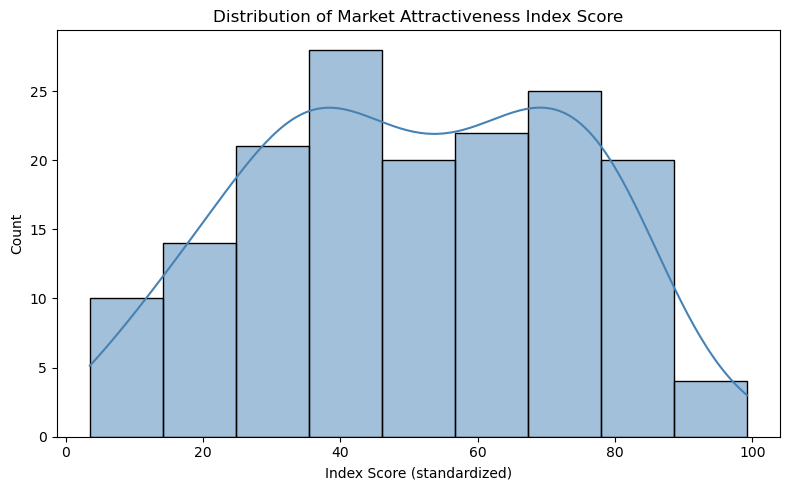

In [60]:
plt.figure(figsize=(8, 5))
sns.histplot(df_scored['Index_Score'], kde=True, color='steelblue')
plt.title("Distribution of Market Attractiveness Index Score")
plt.xlabel("Index Score (standardized)")
plt.tight_layout()
plt.show()

## Visualization: Top 10 Markets

/var/folders/71/lgj4qvd9189g0c_5svy795hh0000gn/T/ipykernel_63264/36348706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Index_Score', y='msa_name', palette='Blues_r')


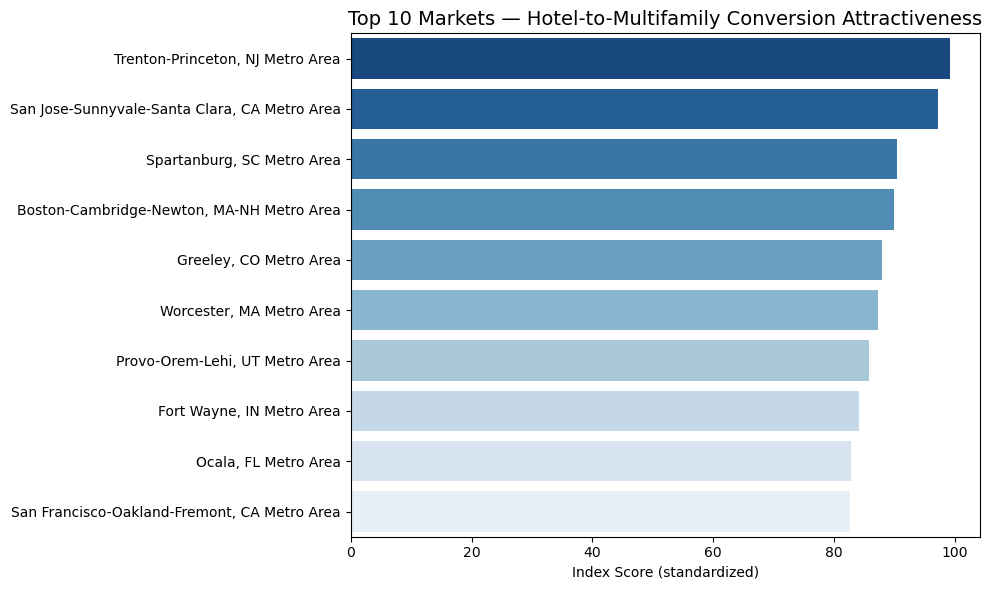

In [61]:
top10 = ranking.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='Index_Score', y='msa_name', palette='Blues_r')
plt.title("Top 10 Markets — Hotel-to-Multifamily Conversion Attractiveness", fontsize=14)
plt.xlabel("Index Score (standardized)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Visualization: Radar Chart — Top 3 Markets

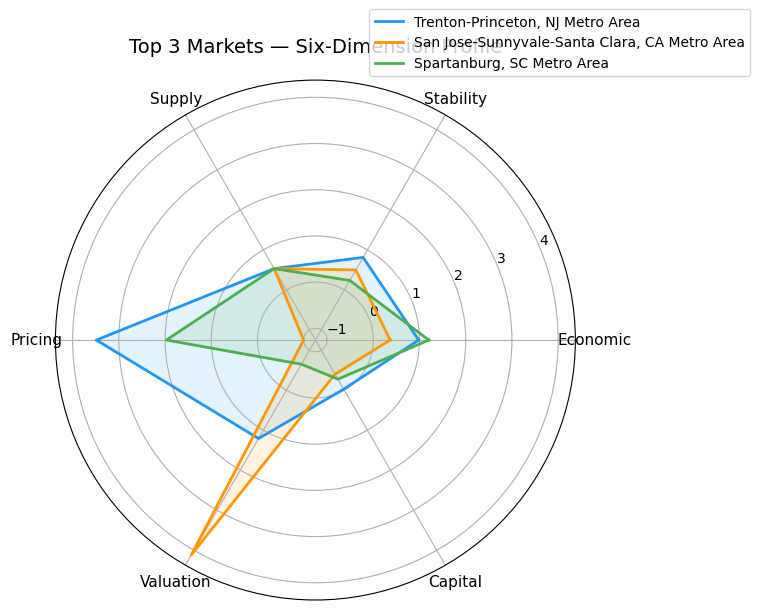

In [46]:
top3 = ranking.head(3)
categories = ['Economic_Index','Stability_Index','Supply_Index',
              'Pricing_Index','Valuation_Index','Capital_Index']
labels = ['Economic','Stability','Supply','Pricing','Valuation','Capital']

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#2196F3', '#FF9800', '#4CAF50']

for i, (_, row) in enumerate(top3.iterrows()):
    values = row[categories].tolist() + [row[categories[0]]]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=row['msa_name'])
    ax.fill(angles, values, color=colors[i], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Top 3 Markets — Six-Dimension Profile", size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

## Visualization: Single MSA Radar Chart

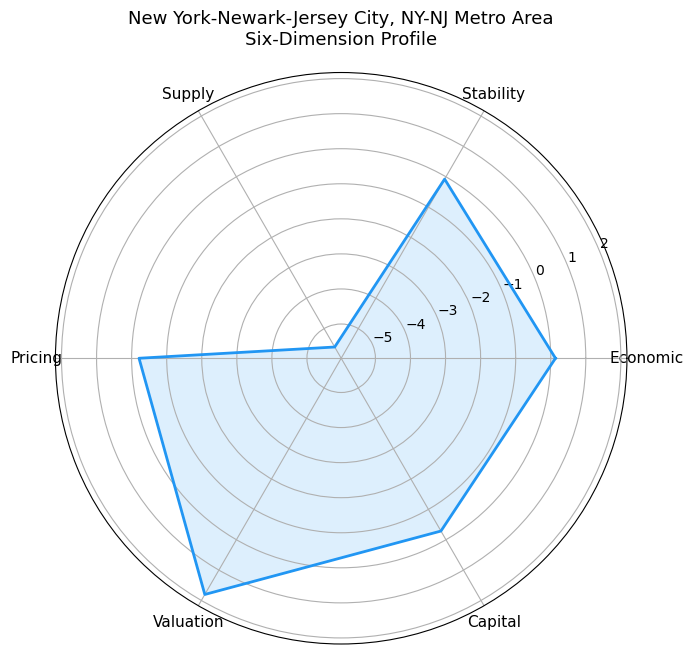

In [47]:
# Change msa_code to any market you want to inspect
target_code = '35620'  # e.g. New York-Newark-Jersey City

categories = ['Economic_Index','Stability_Index','Supply_Index',
              'Pricing_Index','Valuation_Index','Capital_Index']
labels = ['Economic','Stability','Supply','Pricing','Valuation','Capital']

msa_row = df_scored[df_scored['msa_code'] == target_code]

if msa_row.empty:
    print(f"msa_code '{target_code}' not found. Check your OER data coverage.")
else:
    msa_name = msa_row.iloc[0]['msa_name']
    values = msa_row.iloc[0][categories].tolist()

    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, values, color='#2196F3', linewidth=2)
    ax.fill(angles, values, color='#2196F3', alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(f"{msa_name}\nSix-Dimension Profile", size=13, pad=20)
    plt.tight_layout()
    plt.show()

In [62]:
import os
import json

latest_year = int(factor_df['year'].max())
raw_latest = factor_df[factor_df['year'] == latest_year].copy()

# Use current scored results for sub-indices and final index score.
# Keep raw factors from factor_df for the Raw Data tab.
scored_cols = [
    'msa_code',
    'Economic_Index', 'Stability_Index', 'Supply_Index',
    'Pricing_Index', 'Valuation_Index', 'Capital_Index',
    'Index_Score'
]

payload_df = raw_latest.merge(df_scored[scored_cols], on='msa_code', how='inner')
payload_df = payload_df.rename(columns={'Cap Spread': 'Cap_Spread'})

output_cols = [
    'msa_code', 'msa_name',
    'Employment_Rate', 'Employment_Growth', 'Pop_Growth', 'Income_Growth',
    'Vacancy_Rate', 'Rent_to_Income_Ratio', 'New_Multi_Units',
    'Rent_Growth', 'Implied_Value', 'Cap_Spread', 'Diff_Effective_Rate',
    'Economic_Index', 'Stability_Index', 'Supply_Index',
    'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score'
]

payload_df = payload_df[output_cols].dropna().copy()
os.makedirs('data', exist_ok=True)

payload = {
    'year': latest_year,
    'msas': payload_df.round(6).to_dict(orient='records')
}

with open('data/msa_data.json', 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2)

print(f"Exported {len(payload_df)} MSAs -> data/msa_data.json")

Exported 164 MSAs -> data/msa_data.json
